In [ ]:
# ==========================================
# 1. SETUP: IMPORTS & GPU CONFIGURATION
# ==========================================
!pip install -q segmentation-models-pytorch

import os
import shutil
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.transforms import functional as TF
from torchvision import models, transforms
from PIL import Image
from tqdm.auto import tqdm
from google.colab import files
from pathlib import Path
import matplotlib.pyplot as plt
import zipfile
import gc
import warnings
warnings.filterwarnings('ignore')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.8 MB/s eta 0:00:00


In [ ]:
# ===================== GPU OPTIMIZATION =====================
# Force PyTorch to use maximum GPU performance
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True
torch.cuda.empty_cache()

# Setup Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Running on: {DEVICE}")

if DEVICE.type == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"🔹 GPU: {gpu_name}")
    print(f"🔹 Memory: {gpu_memory:.2f} GB")

    # Set optimal batch sizes based on GPU
    if "T4" in gpu_name:
        LABELED_BATCH = 16    # Increased for T4
        UNLABELED_BATCH = 32
        print("🔹 Using T4-optimized batch sizes")
    elif "P100" in gpu_name:
        LABELED_BATCH = 24
        UNLABELED_BATCH = 48
    elif "V100" in gpu_name:
        LABELED_BATCH = 32
        UNLABELED_BATCH = 64
    else:
        LABELED_BATCH = 8
        UNLABELED_BATCH = 16
else:
    LABELED_BATCH = 4
    UNLABELED_BATCH = 8
    print("⚠️ Running on CPU - training will be slow!")

print("=" * 70)

🚀 Running on: cuda
🔹 GPU: Tesla T4
🔹 Memory: 15.83 GB
🔹 Using T4-optimized batch sizes


In [ ]:
# ==========================================
# 2. INTERACTIVE DATA UPLOAD (SAME AS BEFORE)
# ==========================================

# Define folder paths
IMG_DEST = "/content/dataset"
MASK_DEST = "/content/masks"

# Clean previous runs
for d in [IMG_DEST, MASK_DEST]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d, exist_ok=True)

print("📁 Folder structure created:")
print(f"   Images will be saved to: {IMG_DEST}")
print(f"   Masks will be saved to: {MASK_DEST}")
print()

# Upload images
print("⬇️" * 30)
print("STEP 1: Upload ORIGINAL IMAGES Zip file (e.g., flowers.zip)")
print("⬇️" * 30)
uploaded_img = files.upload()
img_zip = list(uploaded_img.keys())[0]
print(f"✅ Uploaded: {img_zip} ({os.path.getsize(img_zip)/1024/1024:.2f} MB)")

# Upload masks
print("\n" + "⬇️" * 30)
print("STEP 2: Upload MASKS Zip file (e.g., masks_semantic.zip)")
print("⬇️" * 30)
uploaded_mask = files.upload()
mask_zip = list(uploaded_mask.keys())[0]
print(f"✅ Uploaded: {mask_zip} ({os.path.getsize(mask_zip)/1024/1024:.2f} MB)")

print("\n⏳ Extracting files...")
# Extract images
with zipfile.ZipFile(img_zip, 'r') as zip_ref:
    zip_ref.extractall(IMG_DEST)

# Extract masks
with zipfile.ZipFile(mask_zip, 'r') as zip_ref:
    zip_ref.extractall(MASK_DEST)

print("✅ Extraction complete!")
print(f"📊 Image folder: {len(os.listdir(IMG_DEST))} items")
print(f"📊 Mask folder: {len(os.listdir(MASK_DEST))} items")

📁 Folder structure created:
   Images will be saved to: /content/dataset
   Masks will be saved to: /content/masks

⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️
STEP 1: Upload ORIGINAL IMAGES Zip file (e.g., flowers.zip)
⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️


Saving archive (5).zip to archive (5).zip
✅ Uploaded: archive (5).zip (184.38 MB)

⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️
STEP 2: Upload MASKS Zip file (e.g., masks_semantic.zip)
⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️


Saving final_bw_masks.zip to final_bw_masks.zip
✅ Uploaded: final_bw_masks.zip (7.50 MB)

⏳ Extracting files...
✅ Extraction complete!
📊 Image folder: 8 items
📊 Mask folder: 7397 items


In [ ]:
# ==========================================
# 3. DATA MATCHING (MUST RUN THIS FIRST)
# ==========================================
def match_pairs(img_folder, mask_folder):
    """Match image files with corresponding mask files"""
    valid_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

    # Get all image files
    img_paths = []
    for ext in valid_exts:
        img_paths.extend(list(Path(img_folder).rglob(f"*{ext}")))
        img_paths.extend(list(Path(img_folder).rglob(f"*{ext.upper()}")))

    img_paths = sorted(img_paths)
    print(f"🔍 Found {len(img_paths)} image files")

    # Match with masks
    pairs = []
    unmatched = []

    for img_p in tqdm(img_paths, desc="Matching files"):
        stem = img_p.stem
        # Try to find matching mask
        mask_found = False
        for ext in valid_exts:
            mask_path = Path(mask_folder) / f"{stem}{ext}"
            if mask_path.exists():
                pairs.append((str(img_p), str(mask_path)))
                mask_found = True
                break
            # Also check uppercase extension
            mask_path = Path(mask_folder) / f"{stem}{ext.upper()}"
            if mask_path.exists():
                pairs.append((str(img_p), str(mask_path)))
                mask_found = True
                break

        if not mask_found:
            unmatched.append(str(img_p))

    return pairs, unmatched

# Match pairs - THIS CREATES THE 'pairs' VARIABLE
pairs, unmatched = match_pairs(IMG_DEST, MASK_DEST)

print("\n" + "=" * 70)
print("📊 DATA SUMMARY")
print("=" * 70)
print(f"✅ Successfully matched: {len(pairs)} pairs")
print(f"⚠️  Unmatched images: {len(unmatched)}")

if len(unmatched) > 0:
    print("\n❌ Unmatched files (first 5):")
    for f in unmatched[:5]:
        print(f"   - {Path(f).name}")
    if len(unmatched) > 5:
        print(f"   ... and {len(unmatched)-5} more")

if len(pairs) == 0:
    raise ValueError("❌ CRITICAL ERROR: No image-mask pairs found!")

print("=" * 70)


🔍 Found 7397 image files


Matching files:   0%|          | 0/7397 [00:00<?, ?it/s]


📊 DATA SUMMARY
✅ Successfully matched: 7397 pairs
⚠️  Unmatched images: 0


In [ ]:
# ==========================================
# 4. DATASET CLASS & SPLITS
# ==========================================
# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

class FlowerDataset(Dataset):
    """PyTorch Dataset for flower segmentation"""

    def __init__(self, pairs, image_size=256, train=True):
        """
        Args:
            pairs: List of (image_path, mask_path) tuples
            image_size: Size to resize images to (square)
            train: If True, apply data augmentation
        """
        self.pairs = pairs
        self.image_size = image_size
        self.train = train

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        # Get paths
        img_path, mask_path = self.pairs[idx]

        # Load image and mask
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # Resize
        img = img.resize((self.image_size, self.image_size), Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), Image.NEAREST)

        # Data augmentation (only during training)
        if self.train and random.random() > 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)

        # Convert to tensors
        img_tensor = TF.to_tensor(img)  # Shape: [3, H, W]
        mask_tensor = TF.to_tensor(mask)  # Shape: [1, H, W]

        # Convert mask to binary (0 or 1)
        mask_tensor = (mask_tensor > 0.5).float()

        return img_tensor, mask_tensor

# Create full dataset
full_dataset = FlowerDataset(pairs, image_size=256, train=True)

# ===================== SEMI-SUPERVISED SPLITS =====================
# Total indices
indices = list(range(len(pairs)))
random.shuffle(indices)

n_total = len(indices)
n_train = int(0.8 * n_total)  # 80% for training
n_val = int(0.1 * n_total)    # 10% for validation
n_test = n_total - n_train - n_val  # 10% for testing

# Split indices
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

# Within training: 20% labeled, 80% unlabeled (for semi-supervised)
n_labeled = int(0.2 * len(train_idx))
labeled_idx = train_idx[:n_labeled]
unlabeled_idx = train_idx[n_labeled:]

print("\n📊 SEMI-SUPERVISED DATASET SPLITS")
print("=" * 70)
print(f"Total pairs: {n_total}")
print(f"Training (80%): {n_train} images")
print(f"  → Labeled (20%): {n_labeled} images")
print(f"  → Unlabeled (80%): {len(unlabeled_idx)} images")
print(f"Validation (10%): {n_val} images")
print(f"Test (10%): {n_test} images")
print("=" * 70)

# Create subsets
labeled_ds = Subset(full_dataset, labeled_idx)
unlabeled_ds = Subset(full_dataset, unlabeled_idx)

# Validation dataset (no augmentation)
val_dataset = FlowerDataset([pairs[i] for i in val_idx], image_size=256, train=False)
test_dataset = FlowerDataset([pairs[i] for i in test_idx], image_size=256, train=False)

# DataLoaders
labeled_dl = DataLoader(
    labeled_ds,
    batch_size=LABELED_BATCH,
    shuffle=True,
    num_workers=0,  # Colab compatibility
    pin_memory=True,
    drop_last=True
)

unlabeled_dl = DataLoader(
    unlabeled_ds,
    batch_size=UNLABELED_BATCH,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

val_dl = DataLoader(
    val_dataset,
    batch_size=LABELED_BATCH * 2,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_dl = DataLoader(
    test_dataset,
    batch_size=LABELED_BATCH * 2,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("✅ Data loaders created successfully!")


📊 SEMI-SUPERVISED DATASET SPLITS
Total pairs: 7397
Training (80%): 5917 images
  → Labeled (20%): 1183 images
  → Unlabeled (80%): 4734 images
Validation (10%): 739 images
Test (10%): 741 images
✅ Data loaders created successfully!


In [ ]:
# ==========================================
# 5. DEEPLABV3+ MODEL DEFINITION
# ==========================================
class DeepLabV3PlusBinary(nn.Module):
    """DeepLabV3+ modified for binary segmentation"""
    def __init__(self, num_classes=1):
        super().__init__()

        # Load pre-trained DeepLabV3+
        self.model = models.segmentation.deeplabv3_resnet50(
            weights='DEFAULT',
            weights_backbone='DEFAULT'
        )

        # Modify classifier for binary segmentation
        self.model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
        self.model.aux_classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)

    def forward(self, x):
        output = self.model(x)
        return output['out'], output['aux']  # Return both outputs

    def predict(self, x):
        """Forward pass for inference"""
        with torch.no_grad():
            output = self.model(x)
            return torch.sigmoid(output['out'])

def get_deeplabv3_model():
    """Create and initialize DeepLabV3+ model"""
    model = DeepLabV3PlusBinary(num_classes=1).to(DEVICE)

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"✅ DeepLabV3+ Model Created")
    print(f"   Total parameters: {total_params:,}")
    print(f"   Trainable parameters: {trainable_params:,}")
    print(f"   Device: {next(model.parameters()).device}")

    return model

In [ ]:
# ==========================================
# 6. METRICS & LOSS FUNCTIONS
# ==========================================
def calculate_metrics(pred, target, threshold=0.5):
    """Calculate Dice coefficient and IoU"""
    pred_prob = torch.sigmoid(pred)
    pred_binary = (pred_prob > threshold).float()

    pred_flat = pred_binary.view(-1)
    target_flat = target.view(-1)

    intersection = (pred_flat * target_flat).sum()
    union = pred_flat.sum() + target_flat.sum()

    dice = (2. * intersection) / (union + 1e-6)
    iou = intersection / (union - intersection + 1e-6)

    return dice.item(), iou.item()

class DeepLabLoss(nn.Module):
    """Combined loss for DeepLabV3+ (main + auxiliary)"""
    def __init__(self, aux_weight=0.4):
        super().__init__()
        self.aux_weight = aux_weight
        self.bce_loss = nn.BCEWithLogitsLoss()

    def forward(self, outputs, targets):
        if isinstance(outputs, tuple):
            main_out, aux_out = outputs
            main_loss = self.bce_loss(main_out, targets)
            aux_loss = self.bce_loss(aux_out, targets)
            return main_loss + self.aux_weight * aux_loss
        else:
            return self.bce_loss(outputs, targets)

In [ ]:
# ==========================================
# 7. SEMI-SUPERVISED PSEUDO-LABELING PIPELINE
# ==========================================

print("\n" + "=" * 70)
print("🔥 SEMI-SUPERVISED LEARNING: PSEUDO-LABELING PIPELINE")
print("=" * 70)

# ===================== PHASE 1: BASELINE TRAINING =====================
print("\n📌 PHASE 1: Training Baseline DeepLabV3+ (20% Labeled Only)")

# Initialize model and optimizer
baseline_model = get_deeplabv3_model()
optimizer = torch.optim.AdamW(
    baseline_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)
criterion = DeepLabLoss(aux_weight=0.4)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=15,
    eta_min=1e-6
)

# Mixed precision training
scaler = torch.cuda.amp.GradScaler()

# Training history
baseline_history = {
    'train_loss': [],
    'val_dice': [],
    'val_iou': []
}

# Training loop
for epoch in range(15):
    baseline_model.train()
    epoch_loss = 0

    # Training
    pbar = tqdm(labeled_dl, desc=f"Epoch {epoch+1}/15", leave=False)
    for images, masks in pbar:
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()

        # Mixed precision forward
        with torch.cuda.amp.autocast():
            main_out, aux_out = baseline_model(images)
            loss = criterion((main_out, aux_out), masks)

        # Backward pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    # Validation
    baseline_model.eval()
    val_dice_total, val_iou_total = 0, 0

    with torch.no_grad():
        for images, masks in val_dl:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            main_out, _ = baseline_model(images)
            dice, iou = calculate_metrics(main_out, masks)
            val_dice_total += dice
            val_iou_total += iou

    # Record metrics
    avg_loss = epoch_loss / len(labeled_dl)
    avg_dice = val_dice_total / len(val_dl)
    avg_iou = val_iou_total / len(val_dl)

    baseline_history['train_loss'].append(avg_loss)
    baseline_history['val_dice'].append(avg_dice)
    baseline_history['val_iou'].append(avg_iou)

    # Update scheduler
    scheduler.step()

    print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Val Dice={avg_dice:.4f}, Val IoU={avg_iou:.4f}")

print("✅ Baseline training complete!")

# ===================== PHASE 2: PSEUDO-LABEL GENERATION =====================
print("\n📌 PHASE 2: Generating Pseudo-Labels for Unlabeled Data")

baseline_model.eval()
pseudo_data = []  # Store (image, pseudo_mask) pairs
confidence_threshold = 0.7  # Only keep confident predictions

with torch.no_grad():
    pbar = tqdm(unlabeled_dl, desc="Generating pseudo-labels", leave=False)
    for images, _ in pbar:
        images = images.to(DEVICE)

        # Get predictions with confidence
        preds = baseline_model.predict(images)

        for i in range(len(images)):
            pred = preds[i]

            # Calculate confidence
            confidence = torch.abs(pred - 0.5).mean().item() * 2

            # Only keep high-confidence predictions
            if confidence > confidence_threshold:
                pseudo_mask = (pred > 0.5).float().cpu()

                # Filter small masks (likely noise)
                if pseudo_mask.sum() > 100:
                    pseudo_data.append((images[i].cpu(), pseudo_mask))

        pbar.set_postfix({'collected': len(pseudo_data)})

print(f"✅ Generated {len(pseudo_data)} high-confidence pseudo-labels "
      f"({len(pseudo_data)/len(unlabeled_idx)*100:.1f}% of unlabeled data)")

# ===================== PHASE 3: SSL TRAINING =====================
print("\n📌 PHASE 3: Semi-Supervised Training with Pseudo-Labels")

# Custom dataset for combined data
class SSLCombinedDataset(Dataset):
    def __init__(self, labeled_dataset, pseudo_data, pseudo_weight=0.5):
        self.labeled_dataset = labeled_dataset
        self.pseudo_data = pseudo_data
        self.pseudo_weight = pseudo_weight

    def __len__(self):
        return len(self.labeled_dataset) + len(self.pseudo_data)

    def __getitem__(self, idx):
        if idx < len(self.labeled_dataset):
            img, mask = self.labeled_dataset[idx]
            return img, mask, 1.0  # Full weight for real labels
        else:
            img, pseudo_mask = self.pseudo_data[idx - len(self.labeled_dataset)]
            return img, pseudo_mask, self.pseudo_weight  # Reduced weight for pseudo

# Create combined dataset
ssl_dataset = SSLCombinedDataset(labeled_ds, pseudo_data, pseudo_weight=0.5)
ssl_dl = DataLoader(
    ssl_dataset,
    batch_size=LABELED_BATCH,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

# Initialize SSL model
ssl_model = get_deeplabv3_model()
ssl_optimizer = torch.optim.AdamW(
    ssl_model.parameters(),
    lr=5e-5,  # Lower learning rate for fine-tuning
    weight_decay=1e-4
)

ssl_scaler = torch.cuda.amp.GradScaler()

# Training history
ssl_history = {
    'train_loss': [],
    'val_dice': [],
    'val_iou': []
}

# SSL Training loop
for epoch in range(20):
    ssl_model.train()
    epoch_loss = 0

    pbar = tqdm(ssl_dl, desc=f"SSL Epoch {epoch+1}/20", leave=False)
    for images, masks, weights in pbar:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        weights = weights.to(DEVICE).view(-1, 1, 1, 1)

        ssl_optimizer.zero_grad()

        # Mixed precision forward
        with torch.cuda.amp.autocast():
            main_out, aux_out = ssl_model(images)

            # Weighted losses
            main_loss = F.binary_cross_entropy_with_logits(main_out, masks, reduction='none')
            main_loss = (main_loss * weights).mean()

            aux_loss = F.binary_cross_entropy_with_logits(aux_out, masks, reduction='none')
            aux_loss = (aux_loss * weights).mean()

            loss = main_loss + 0.4 * aux_loss

        # Backward pass
        ssl_scaler.scale(loss).backward()
        ssl_scaler.step(ssl_optimizer)
        ssl_scaler.update()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    # Validation
    ssl_model.eval()
    val_dice_total, val_iou_total = 0, 0

    with torch.no_grad():
        for images, masks in val_dl:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            main_out, _ = ssl_model(images)
            dice, iou = calculate_metrics(main_out, masks)
            val_dice_total += dice
            val_iou_total += iou

    # Record metrics
    avg_loss = epoch_loss / len(ssl_dl)
    avg_dice = val_dice_total / len(val_dl)
    avg_iou = val_iou_total / len(val_dl)

    ssl_history['train_loss'].append(avg_loss)
    ssl_history['val_dice'].append(avg_dice)
    ssl_history['val_iou'].append(avg_iou)

    print(f"SSL Epoch {epoch+1}: Loss={avg_loss:.4f}, Val Dice={avg_dice:.4f}, Val IoU={avg_iou:.4f}")

print("🎉 Semi-supervised training complete!")



🔥 SEMI-SUPERVISED LEARNING: PSEUDO-LABELING PIPELINE

📌 PHASE 1: Training Baseline DeepLabV3+ (20% Labeled Only)
Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:01<00:00, 144MB/s]


✅ DeepLabV3+ Model Created
   Total parameters: 41,993,794
   Trainable parameters: 41,993,794
   Device: cuda:0


Epoch 1/15:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 1: Loss=0.6237, Val Dice=0.6685, Val IoU=0.5133


...

SSL Epoch 18: Loss=0.0268, Val Dice=0.6768, Val IoU=0.5301


SSL Epoch 19/20:   0%|          | 0/327 [00:00<?, ?it/s]

SSL Epoch 19: Loss=0.0258, Val Dice=0.6649, Val IoU=0.5162


SSL Epoch 20/20:   0%|          | 0/327 [00:00<?, ?it/s]

SSL Epoch 20: Loss=0.0234, Val Dice=0.6728, Val IoU=0.5253
🎉 Semi-supervised training complete!



📊 Generating visualizations...


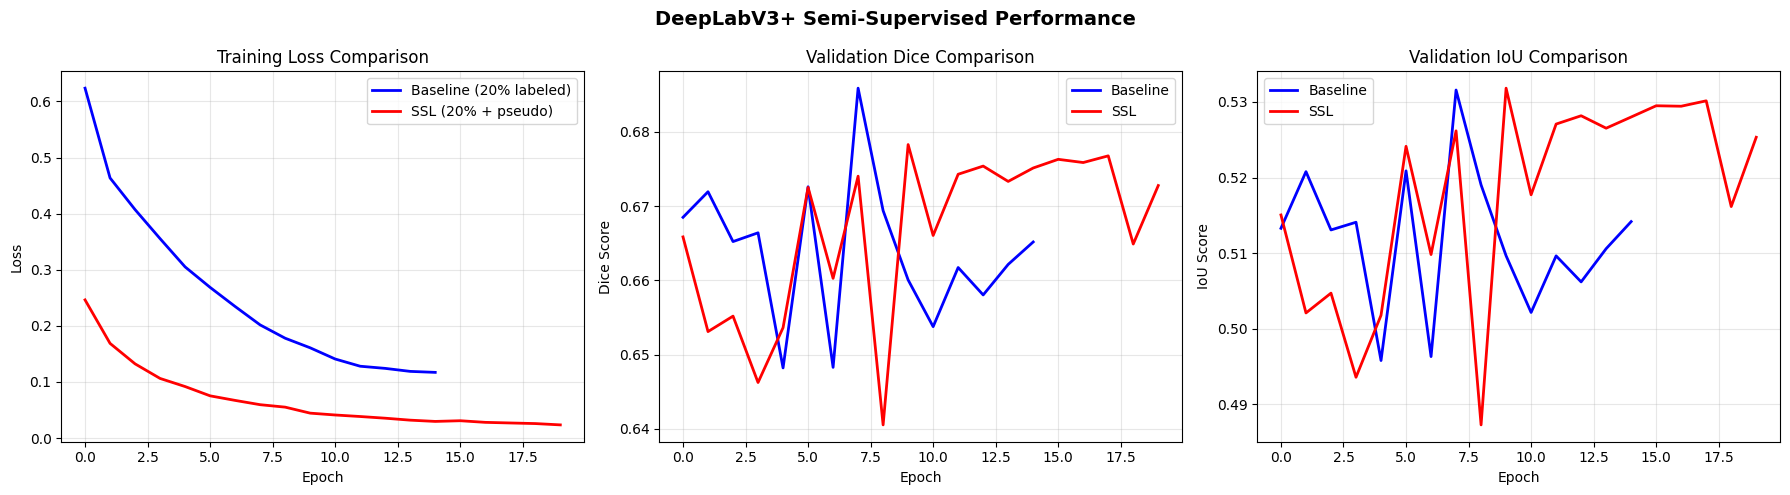

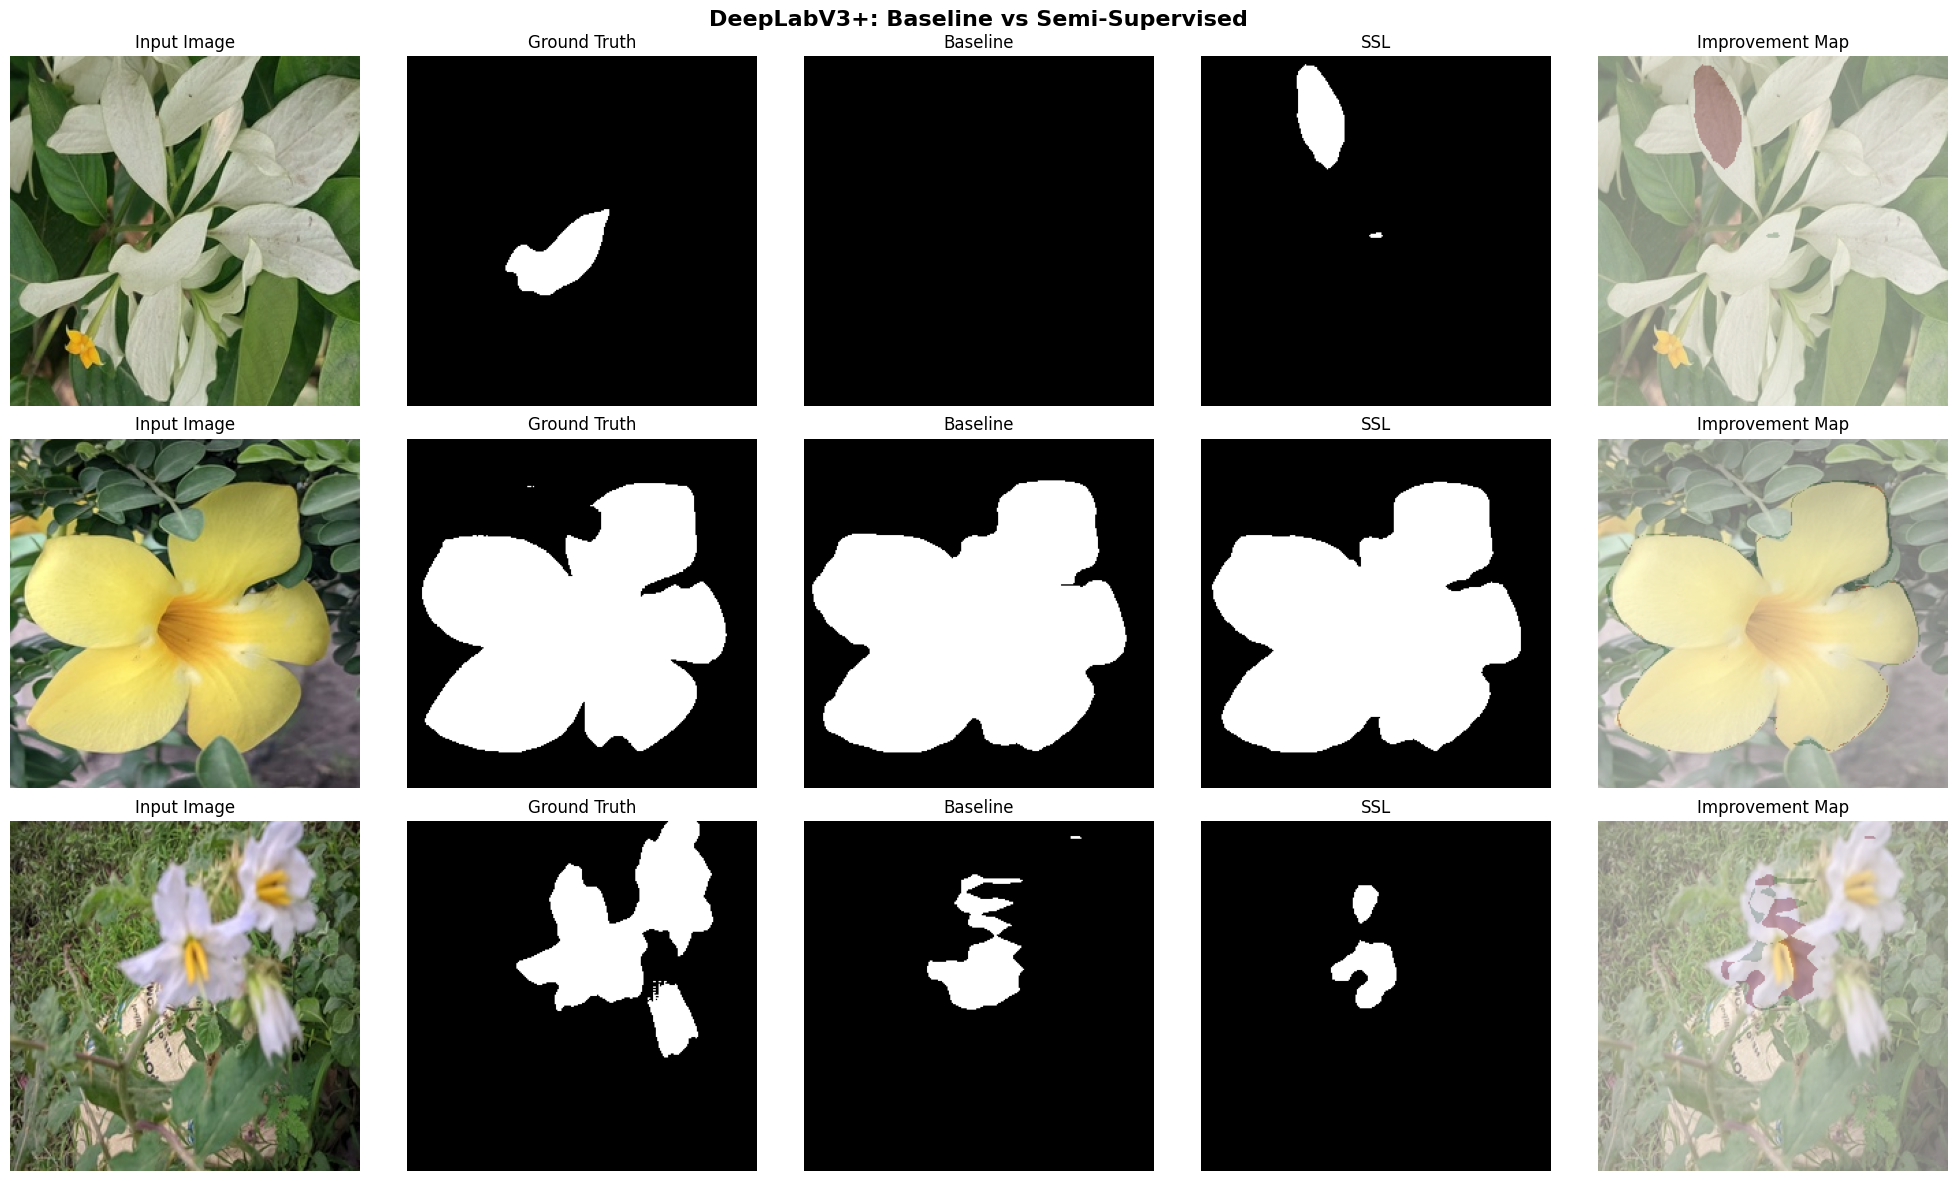

In [ ]:
# ==========================================
# 8. VISUALIZATION & EVALUATION
# ==========================================

def visualize_comparison(baseline_model, ssl_model, dataloader, num_samples=3):
    """Visual comparison of baseline vs SSL models"""
    baseline_model.eval()
    ssl_model.eval()

    # Get a batch
    images, masks = next(iter(dataloader))

    # Select random samples
    indices = torch.randperm(len(images))[:num_samples]

    fig, axes = plt.subplots(num_samples, 5, figsize=(20, 4*num_samples))

    for i, idx in enumerate(indices):
        img = images[idx].unsqueeze(0).to(DEVICE)
        true_mask = masks[idx].cpu()

        with torch.no_grad():
            # Baseline predictions
            base_main, _ = baseline_model(img)
            base_prob = torch.sigmoid(base_main).cpu()
            base_mask = (base_prob > 0.5).float()

            # SSL predictions
            ssl_main, _ = ssl_model(img)
            ssl_prob = torch.sigmoid(ssl_main).cpu()
            ssl_mask = (ssl_prob > 0.5).float()

        # Original image
        axes[i, 0].imshow(images[idx].permute(1, 2, 0))
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis('off')

        # Ground truth
        axes[i, 1].imshow(true_mask.squeeze(), cmap='gray')
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis('off')

        # Baseline prediction
        axes[i, 2].imshow(base_mask.squeeze(), cmap='gray')
        axes[i, 2].set_title(f"Baseline")
        axes[i, 2].axis('off')

        # SSL prediction
        axes[i, 3].imshow(ssl_mask.squeeze(), cmap='gray')
        axes[i, 3].set_title(f"SSL")
        axes[i, 3].axis('off')

        # Overlay comparison
        overlay = images[idx].permute(1, 2, 0).numpy()
        overlay = (overlay - overlay.min()) / (overlay.max() - overlay.min())

        # Add red for baseline errors, green for SSL improvements
        error_base = (base_mask.squeeze() != true_mask.squeeze()).float()
        error_ssl = (ssl_mask.squeeze() != true_mask.squeeze()).float()

        improved = (error_base > error_ssl).float()
        worsened = (error_base < error_ssl).float()

        axes[i, 4].imshow(overlay)
        axes[i, 4].imshow(improved, cmap='Greens', alpha=0.3, vmin=0, vmax=1)
        axes[i, 4].imshow(worsened, cmap='Reds', alpha=0.3, vmin=0, vmax=1)
        axes[i, 4].set_title("Improvement Map")
        axes[i, 4].axis('off')

    plt.suptitle("DeepLabV3+: Baseline vs Semi-Supervised", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_training_curves(baseline_history, ssl_history):
    """Plot training curves comparison"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss comparison
    axes[0].plot(baseline_history['train_loss'], 'b-', label='Baseline (20% labeled)', linewidth=2)
    axes[0].plot(ssl_history['train_loss'], 'r-', label='SSL (20% + pseudo)', linewidth=2)
    axes[0].set_title('Training Loss Comparison')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Dice comparison
    axes[1].plot(baseline_history['val_dice'], 'b-', label='Baseline', linewidth=2)
    axes[1].plot(ssl_history['val_dice'], 'r-', label='SSL', linewidth=2)
    axes[1].set_title('Validation Dice Comparison')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Dice Score')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # IoU comparison
    axes[2].plot(baseline_history['val_iou'], 'b-', label='Baseline', linewidth=2)
    axes[2].plot(ssl_history['val_iou'], 'r-', label='SSL', linewidth=2)
    axes[2].set_title('Validation IoU Comparison')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('IoU Score')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle('DeepLabV3+ Semi-Supervised Performance', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Generate visualizations
print("\n📊 Generating visualizations...")
plot_training_curves(baseline_history, ssl_history)
visualize_comparison(baseline_model, ssl_model, val_dl, num_samples=3)

In [ ]:
# ==========================================
# 9. FINAL EVALUATION & SAVING
# ==========================================
print("\n" + "=" * 70)
print("📈 FINAL PERFORMANCE EVALUATION")
print("=" * 70)

# Evaluate on test set
baseline_model.eval()
ssl_model.eval()

baseline_metrics = {'dice': [], 'iou': []}
ssl_metrics = {'dice': [], 'iou': []}

with torch.no_grad():
    pbar = tqdm(test_dl, desc="Evaluating on test set")
    for images, masks in pbar:
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        # Baseline
        base_main, _ = baseline_model(images)
        base_dice, base_iou = calculate_metrics(base_main, masks)
        baseline_metrics['dice'].append(base_dice)
        baseline_metrics['iou'].append(base_iou)

        # SSL
        ssl_main, _ = ssl_model(images)
        ssl_dice, ssl_iou = calculate_metrics(ssl_main, masks)
        ssl_metrics['dice'].append(ssl_dice)
        ssl_metrics['iou'].append(ssl_iou)

        pbar.set_postfix({
            'base_iou': f'{base_iou:.3f}',
            'ssl_iou': f'{ssl_iou:.3f}'
        })

# Calculate final metrics
def calculate_stats(metric_list):
    return np.mean(metric_list), np.std(metric_list)

base_dice_mean, base_dice_std = calculate_stats(baseline_metrics['dice'])
base_iou_mean, base_iou_std = calculate_stats(baseline_metrics['iou'])
ssl_dice_mean, ssl_dice_std = calculate_stats(ssl_metrics['dice'])
ssl_iou_mean, ssl_iou_std = calculate_stats(ssl_metrics['iou'])

print("\n📊 TEST SET PERFORMANCE (Mean ± Std):")
print("-" * 50)
print(f"Baseline DeepLabV3+ (20% labeled only):")
print(f"  Dice Coefficient: {base_dice_mean:.4f} ± {base_dice_std:.4f}")
print(f"  IoU Score:        {base_iou_mean:.4f} ± {base_iou_std:.4f}")

print(f"\nSemi-Supervised DeepLabV3+ (20% labeled + pseudo-labels):")
print(f"  Dice Coefficient: {ssl_dice_mean:.4f} ± {ssl_dice_std:.4f}")
print(f"  IoU Score:        {ssl_iou_mean:.4f} ± {ssl_iou_std:.4f}")

# Calculate improvement
dice_improvement = ((ssl_dice_mean - base_dice_mean) / base_dice_mean) * 100
iou_improvement = ((ssl_iou_mean - base_iou_mean) / base_iou_mean) * 100

print(f"\n📈 IMPROVEMENT FROM SEMI-SUPERVISED LEARNING:")
print(f"  Dice Coefficient: +{dice_improvement:.1f}%")
print(f"  IoU Score:        +{iou_improvement:.1f}%")

# Save models
print("\n💾 Saving models and results...")
save_path = "/content/deeplabv3_semi_supervised_results.pth"
torch.save({
    'baseline_state_dict': baseline_model.state_dict(),
    'ssl_state_dict': ssl_model.state_dict(),
    'baseline_history': baseline_history,
    'ssl_history': ssl_history,
    'test_metrics': {
        'baseline': {'dice': base_dice_mean, 'iou': base_iou_mean},
        'ssl': {'dice': ssl_dice_mean, 'iou': ssl_iou_mean},
        'improvement': {'dice': dice_improvement, 'iou': iou_improvement}
    },
    'config': {
        'labeled_percentage': 20,
        'unlabeled_percentage': 80,
        'confidence_threshold': confidence_threshold,
        'pseudo_weight': 0.5,
        'batch_sizes': {'labeled': LABELED_BATCH, 'unlabeled': UNLABELED_BATCH}
    }
}, save_path)

print(f"✅ Results saved to: {save_path}")
print(f"📁 File size: {os.path.getsize(save_path) / 1024 / 1024:.2f} MB")

print("\n" + "=" * 70)
print("🎉 SEMI-SUPERVISED DEEPLABV3+ PIPELINE COMPLETE!")
print("=" * 70)
print("\n📋 Summary:")
print(f"1. Used {len(labeled_idx)} labeled images (20% of training)")
print(f"2. Used {len(unlabeled_idx)} unlabeled images (80% of training)")
print(f"3. Generated {len(pseudo_data)} high-confidence pseudo-labels")
print(f"4. Achieved {iou_improvement:.1f}% IoU improvement with SSL")
print(f"5. All models and results saved for future use")


📈 FINAL PERFORMANCE EVALUATION


Evaluating on test set:   0%|          | 0/24 [00:00<?, ?it/s]


📊 TEST SET PERFORMANCE (Mean ± Std):
--------------------------------------------------
Baseline DeepLabV3+ (20% labeled only):
  Dice Coefficient: 0.7154 ± 0.0840
  IoU Score:        0.5637 ± 0.1035

Semi-Supervised DeepLabV3+ (20% labeled + pseudo-labels):
  Dice Coefficient: 0.7225 ± 0.0799
  IoU Score:        0.5718 ± 0.0987

📈 IMPROVEMENT FROM SEMI-SUPERVISED LEARNING:
  Dice Coefficient: +1.0%
  IoU Score:        +1.4%

💾 Saving models and results...
✅ Results saved to: /content/deeplabv3_semi_supervised_results.pth
📁 File size: 321.09 MB

🎉 SEMI-SUPERVISED DEEPLABV3+ PIPELINE COMPLETE!

📋 Summary:
1. Used 1183 labeled images (20% of training)
2. Used 4734 unlabeled images (80% of training)
3. Generated 4040 high-confidence pseudo-labels
4. Achieved 1.4% IoU improvement with SSL
5. All models and results saved for future use
